# Testing Architecture on multiple cities

The previous notebooks relied on creating different models, understanding them and studying how they learned through the study of attention.
Now we will try to explore the performances of models that combined both the message passing and the attention mechanism.
We will use the same dataset as before, but we will try to train the model on multiple cities at once.


## Preprocessing part

In [48]:
import torch    
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from collections import Counter
from torch_geometric.data import InMemoryDataset, Data
import torch_geometric
from torch_geometric.nn import GATv2Conv
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.nn.attention import PerformerAttention
from torch_geometric.nn import GATConv


In [49]:
# load the data
city_list = ['PC','CR','PU','TR','RI']
node_columns = ['osmid', 'y', 'x', 'street_count', 'bc', 'traffic_lights', 'geometry']
nodes = {}
edges = {}

for city in city_list:
    nodes[city] = gpd.read_file(f'nodes_{city}.geojson')
    edges[city] = gpd.read_file(f'edges_{city}.geojson')

    # Filter columns (should be in the same loop)
    nodes[city] = nodes[city][[col for col in nodes[city].columns if col in node_columns]]

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5
Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5
Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5
Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field wid

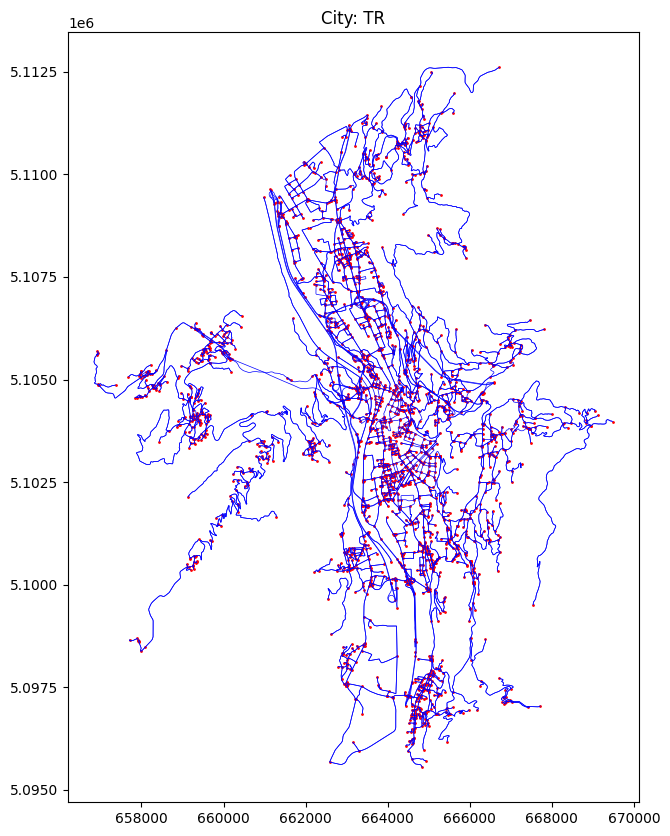

In [50]:
def plot_city(city):
    fig, ax = plt.subplots(figsize=(10, 10))
    nodes[city].plot(ax=ax, color='red', markersize=1)
    edges[city].plot(ax=ax, color='blue', linewidth=0.5)
    plt.title(f'City: {city}')
    plt.show()

# Plot a city
plot_city('TR')

Preparing the data

In [51]:
# Preprocess the data and prepare the dataset
def preprocess_data(nodes, edges):
    scaler = StandardScaler()
    # X only needs to drop geometry
    X = nodes.drop(columns=['geometry']).values
    X = np.array(X)
    X = scaler.fit_transform(X)
    
    # Y is the traffic speed
    Y = edges['traffic_speed'].values
    Y = np.array(Y)

    # Edge index
    # Prepare edge index 
    node_to_id = {}
    for i, node in enumerate(nodes['osmid'].values):
        node_to_id[node] = i

    start_node = [node_to_id[i] for i in edges['u'].values]
    end_node = [node_to_id[i] for i in edges['v'].values]
    start = torch.tensor(start_node, dtype=torch.long)
    end = torch.tensor(end_node, dtype=torch.long)
    edge_index = torch.stack([start, end], dim=0)

    transform = T.AddRandomWalkPE( walk_length= 20, attr_name= 'pe')
    data = Data(x = torch.FloatTensor(X), y = torch.FloatTensor(Y), edge_index = edge_index )
    data = transform(data)


    np.random.seed(0)
        
    n_edges = data.num_edges
    indices = np.random.permutation(n_edges)
            
    train_idx = indices[:int(0.7 * n_edges)]
    #print(len(train_idx)) #debug
    val_idx = indices[int(0.7 * n_edges):int(0.85 * n_edges)]
    #print(len(val_idx)) #debug
    test_idx = indices[int(0.85 * n_edges):]
    #print(len(test_idx)) #debug
            
    # Create masks
    train_mask = torch.zeros(n_edges, dtype=torch.bool)
    val_mask = torch.zeros(n_edges, dtype=torch.bool)
    test_mask = torch.zeros(n_edges, dtype=torch.bool)
        
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
            
    data.train_mask = train_mask    #size is still all nodes but only True for train nodes
    data.val_mask = val_mask
    data.test_mask = test_mask
        
    return data
data = preprocess_data(nodes['TR'], edges['TR'])
print(data)

Data(x=[2904, 6], edge_index=[2, 6151], y=[6151], pe=[2904, 20], train_mask=[6151], val_mask=[6151], test_mask=[6151])


In [52]:
#check the target
max(data.y - np.array(edges['TR']['traffic_speed'].values))

tensor(5.7220e-06, dtype=torch.float64)

Everything works so it's time to create the real dataset and data loader

In [53]:
# Preprocess all the cities
processed_data = {}
for city in city_list:
    print(f"Processing city: {city}")
    processed_data[city] = preprocess_data(nodes[city], edges[city])
    print(f"Processed {city} with {processed_data[city].num_nodes} nodes and {processed_data[city].num_edges} edges.")
# Verify all cities were processed
print("\nProcessed cities:")
for city, data in processed_data.items():
    print(f"- {city}: {data.num_nodes} nodes, {data.num_edges} edges")

Processing city: PC
Processed PC with 3231 nodes and 6930 edges.
Processing city: CR
Processed CR with 2280 nodes and 4786 edges.
Processing city: PU
Processed PU with 3849 nodes and 8164 edges.
Processing city: TR
Processed TR with 2904 nodes and 6151 edges.
Processing city: RI
Processed RI with 6008 nodes and 12464 edges.

Processed cities:
- PC: 3231 nodes, 6930 edges
- CR: 2280 nodes, 4786 edges
- PU: 3849 nodes, 8164 edges
- TR: 2904 nodes, 6151 edges
- RI: 6008 nodes, 12464 edges


In [54]:
# Data Loader
from torch_geometric.loader import DataLoader

data_list = list(processed_data.values())
loader = DataLoader(data_list, batch_size=1, shuffle=True)
for batch in loader:
    print(f"Batch with {batch.num_nodes} nodes and {batch.num_edges} edges")

Batch with 3849 nodes and 8164 edges
Batch with 2904 nodes and 6151 edges
Batch with 2280 nodes and 4786 edges
Batch with 6008 nodes and 12464 edges
Batch with 3231 nodes and 6930 edges


## First model is not quite like GPS:
It combines Performer and GNN but only at the end of the embedding process.

In [93]:
from torch_geometric.nn.attention import PerformerAttention
from torch_geometric.nn import GATConv

device = 'cpu' #GAT do not support mps yet
class HybridModel(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_transformer_layers: int = 2,
        num_gat_layers: int = 2,
        dropout: float = 0.4,
        combine_method: str = 'concat',  # 'concat', 'sum'
    ):
        super().__init__()
        
        # Shared input embedding for Performer branch
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        # Transformer branch (DeepGraphPerformer)
        self.transformer_layers = nn.ModuleList()
        for _ in range(num_transformer_layers):
            layer = nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_channels),
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                'norm2': nn.LayerNorm(hidden_channels),
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.transformer_layers.append(layer)
        
        # GAT branch
        self.gat_layers = nn.ModuleList()
        for i in range(num_gat_layers):
            input_dim = hidden_channels if i > 0 else in_channels
            heads = heads if i < num_gat_layers - 1 else 1  # Last layer has no multi-head
            self.gat_layers.append(
                GATConv(input_dim, hidden_channels // heads, heads=heads, concat=True, dropout=dropout)
            )
        
        # Combination method
        self.combine_method = combine_method
        if combine_method == 'concat':
            self.combine = nn.Linear(hidden_channels * 2, hidden_channels)
        
        # Output layer for edge prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe, edge_index, batch=None):
        # Initial embedding for both branches
        x_pe = self.pe_norm(pe)
        transformer_x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Transformer branch
        for layer in self.transformer_layers:
            # Attention block with residual
            residual = transformer_x
            transformer_x_norm = layer['norm1'](transformer_x)
            transformer_x_attn = transformer_x_norm.unsqueeze(0)
            transformer_x_attn = layer['attention'](transformer_x_attn)
            transformer_x = transformer_x_attn.squeeze(0) + residual
            
            # FFN block with residual
            residual = transformer_x
            transformer_x = layer['norm2'](transformer_x)
            transformer_x = layer['ffn'](transformer_x) + residual
        
        # GAT branch
        gat_x = x
        for i, gat_layer in enumerate(self.gat_layers):
            gat_x = gat_layer(gat_x, edge_index)
            if i < len(self.gat_layers) - 1:  # Not the last layer
                gat_x = F.relu(gat_x)
                gat_x = F.dropout(gat_x, p=0.4, training=self.training)
        
        # Combine the two embeddings
        if self.combine_method == 'sum':
            combined_x = transformer_x + gat_x
        elif self.combine_method == 'concat':
            combined_x = torch.cat([transformer_x, gat_x], dim=1)
            combined_x = F.relu(self.combine(combined_x))
        
        # Edge prediction
        src, dst = edge_index
        edge_features = torch.cat([combined_x[src], combined_x[dst]], dim=1)
        edge_pred = self.output_layer(edge_features)
        
        return edge_pred
    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.transformer_layers:
            attention = layer['attention']
            attention.redraw_projection_matrix()

In [94]:
model = HybridModel(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)

HybridModel(
  (node_emb): Linear(in_features=6, out_features=48, bias=True)
  (pe_lin): Linear(in_features=20, out_features=16, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (transformer_layers): ModuleList(
    (0-1): 2 x ModuleDict(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): PerformerAttention(heads=4, head_channels=16 kernel=ReLU())
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): Dropout(p=0.4, inplace=False)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
    )
  )
  (gat_layers): ModuleList(
    (0): GATConv(6, 16, heads=4)
    (1): GATConv(64, 64, heads=1)
  )
  (output_layer): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3):

In [95]:
# Train and evaluate the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=60)
redraw_freq = 30
def train(model, data):
    model.train()
    optimizer.zero_grad()
    if epoch % redraw_freq == 0:
        model.redraw_projection_matrix()
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    loss = criterion(predictions[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()
def test(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask]
        pred = pred.squeeze(-1)
        true = data.y[mask]
        loss = criterion(pred, true)
        return loss.item()

In [96]:
# Train loop
EPOCHS = 1000
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # Reset epoch losses
    epoch_train_loss = 0
    epoch_val_loss = 0
    num_batches = 0
    
    # Process all batches in an epoch
    for batch in loader:
        batch = batch.to(device)
        train_loss = train(model, batch)
        val_loss = test(model, batch, batch.val_mask)
        
        # Accumulate batch losses
        epoch_train_loss += train_loss
        epoch_val_loss += val_loss
        num_batches += 1
    
    # Calculate average losses for the epoch
    epoch_train_loss /= num_batches
    epoch_val_loss /= num_batches
    
    # Record epoch losses
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    # Scheduler step with average validation loss
    scheduler.step(epoch_val_loss)
    
    # Early stopping based on epoch validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

Epoch 10: Train Loss: 123.6749, Val Loss: 90.1865
Epoch 20: Train Loss: 105.9842, Val Loss: 68.3858
Epoch 30: Train Loss: 100.7254, Val Loss: 67.7659
Epoch 40: Train Loss: 96.0248, Val Loss: 65.5174
Epoch 50: Train Loss: 94.7238, Val Loss: 63.2137
Epoch 60: Train Loss: 96.2311, Val Loss: 63.1925
Epoch 70: Train Loss: 92.8632, Val Loss: 59.9485
Epoch 80: Train Loss: 89.3937, Val Loss: 57.5240
Epoch 90: Train Loss: 94.8542, Val Loss: 60.3428
Epoch 100: Train Loss: 90.2431, Val Loss: 56.3873
Epoch 110: Train Loss: 85.9405, Val Loss: 56.7099
Epoch 120: Train Loss: 97.4424, Val Loss: 60.9108
Epoch 130: Train Loss: 83.9648, Val Loss: 55.5701
Epoch 140: Train Loss: 81.1961, Val Loss: 54.3797
Epoch 150: Train Loss: 92.4201, Val Loss: 64.8682
Epoch 160: Train Loss: 83.6639, Val Loss: 55.9856
Epoch 170: Train Loss: 80.1048, Val Loss: 53.7161
Epoch 180: Train Loss: 93.6723, Val Loss: 58.1245
Epoch 190: Train Loss: 81.4370, Val Loss: 54.7461
Epoch 200: Train Loss: 78.4077, Val Loss: 53.1744
Epoch 

In [98]:
# load the best model
model = HybridModel(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)

# Evaluate the model on the test set per city
test_losses = {}
for city, data in processed_data.items():
    data = data.to(device)
    test_loss = test(model, data, data.test_mask)
    test_losses[city] = test_loss
    print(f"Test Loss for {city}: {test_loss:.4f}")

Test Loss for PC: 52.4440
Test Loss for CR: 45.6446
Test Loss for PU: 51.0148
Test Loss for TR: 50.9860
Test Loss for RI: 39.2667


In [99]:
#plot the predictions per city
def plot_predictions(city, model, data, edges):
    edges = edges[city]
    data = data[city].to(device)
    model.eval()
    with torch.no_grad():        
        pred = model(data.x, data.pe, data.edge_index).squeeze(-1)
        edges['predicted_speed'] = pred.cpu().numpy()

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        edges.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis')
        ax1.set_title('True Traffic Speed')
        edges.plot(column='predicted_speed', ax=ax2, legend=True, cmap='viridis')
        ax2.set_title('Predicted Traffic Speed')
        plt.suptitle(f'City: {city}')
        plt.tight_layout()
        plt.show()
        

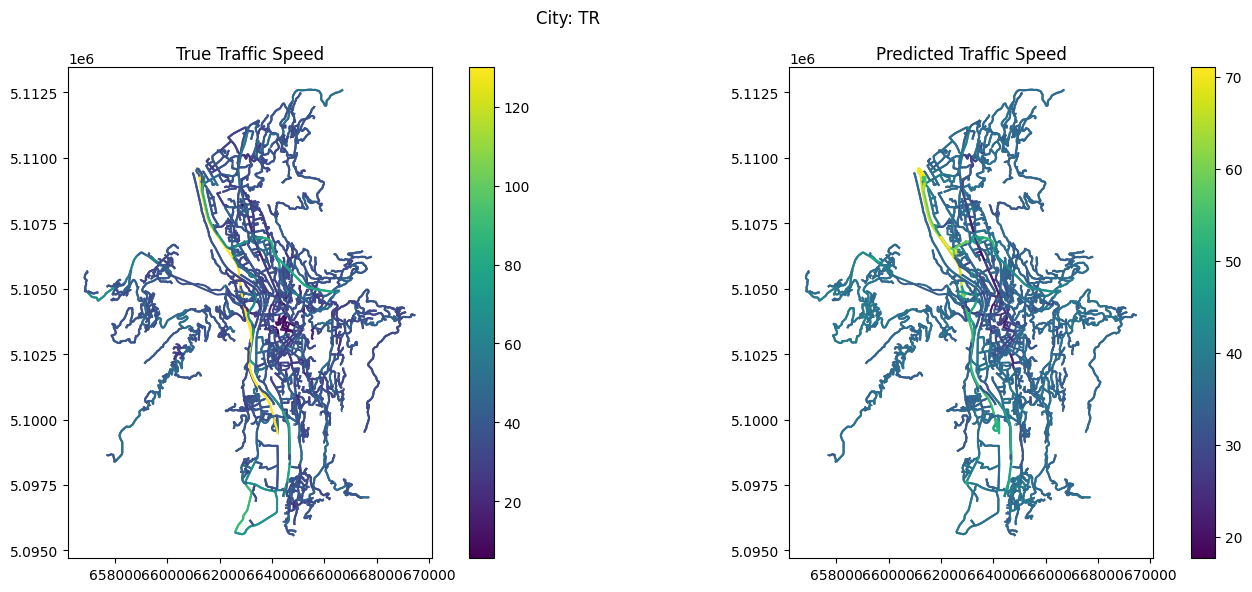

In [104]:
plot_predictions('TR', model, processed_data, edges)

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


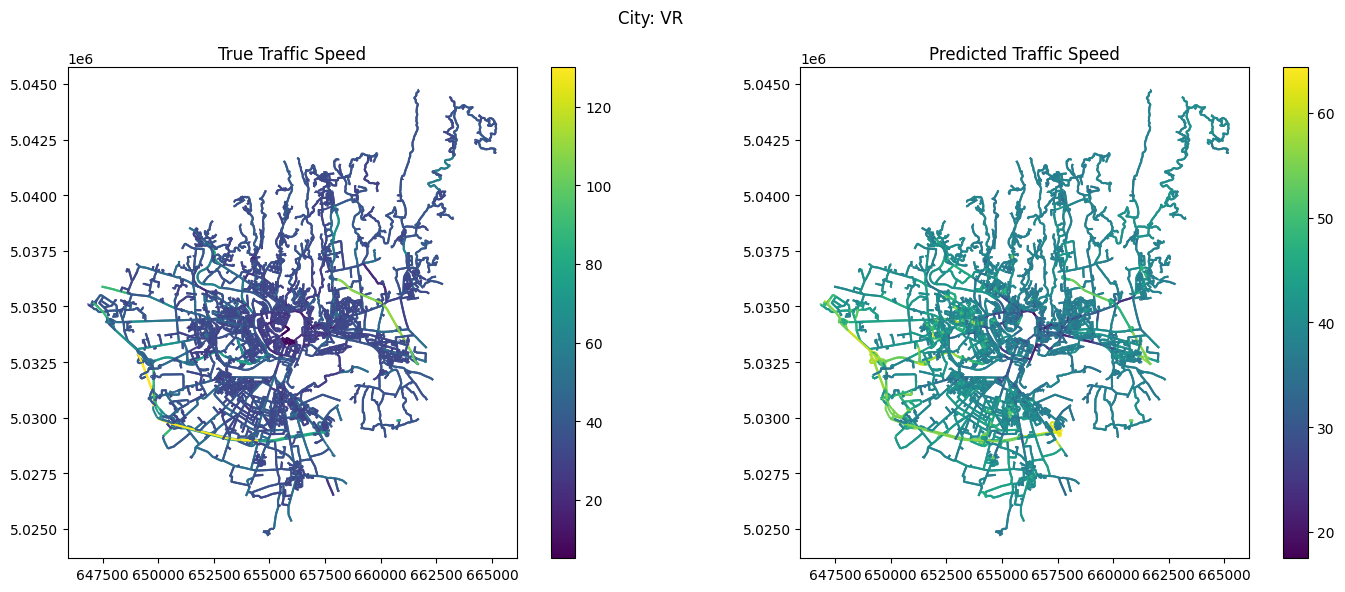

Test Loss for VR: 75.0742


In [105]:
#import a new city to test
nodes_vr = gpd.read_file(f'nodes_VR.geojson')
edges_vr = gpd.read_file(f'edges_VR.geojson')

nodes_vr = nodes_vr[[col for col in nodes_vr.columns if col in node_columns]]

vr_data = preprocess_data(nodes_vr, edges_vr)
plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})
# compute loss
loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {loss:.4f}")

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5


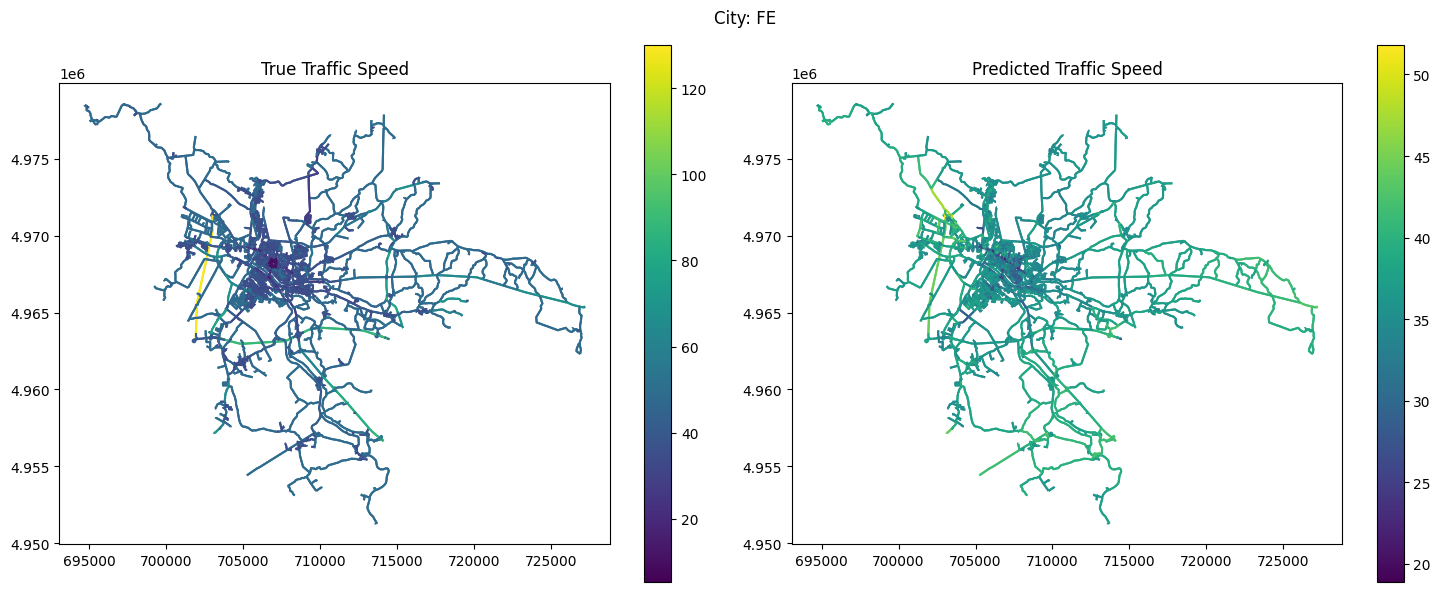

Test Loss for FE: 88.8405


In [106]:
#import a new city to test
nodes_fe = gpd.read_file(f'nodes_FE.geojson')
edges_fe = gpd.read_file(f'edges_FE.geojson')

nodes_fe = nodes_fe[[col for col in nodes_fe.columns if col in node_columns]]

fe_data = preprocess_data(nodes_fe, edges_fe)
plot_predictions('FE', model, {'FE': fe_data}, {'FE': edges_fe})
# compute loss
loss = test(model, fe_data, fe_data.test_mask)
print(f"Test Loss for FE: {loss:.4f}")

## 1.5 model is the same as the first one but with the GNN part that also receives the positional encoding.

In [107]:
device = 'cpu' #GAT do not support mps yet
class HybridModel_variant(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_transformer_layers: int = 2,
        num_gat_layers: int = 2,
        dropout: float = 0.4,
        combine_method: str = 'concat',  # 'concat', 'sum'
    ):
        super().__init__()
        
        # Shared input embedding for Performer branch
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        # Transformer branch (DeepGraphPerformer)
        self.transformer_layers = nn.ModuleList()
        for _ in range(num_transformer_layers):
            layer = nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_channels),
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                'norm2': nn.LayerNorm(hidden_channels),
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.transformer_layers.append(layer)
        
        # GAT branch
        self.gat_layers = nn.ModuleList()
        for i in range(num_gat_layers):
            input_dim = hidden_channels if i > 0 else hidden_channels
            heads = heads if i < num_gat_layers - 1 else 1  # Last layer has no multi-head
            self.gat_layers.append(
                GATConv(input_dim, hidden_channels // heads, heads=heads, concat=True, dropout=dropout)
            )
        
        # Combination method
        self.combine_method = combine_method
        if combine_method == 'concat':
            self.combine = nn.Linear(hidden_channels * 2, hidden_channels)
        
        # Output layer for edge prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe, edge_index, batch=None):
        # Initial embedding for both branches
        x_pe = self.pe_norm(pe)
        # Initial embedding for both branches
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        transformer_x = x
        
        # Transformer branch
        for layer in self.transformer_layers:
            # Attention block with residual
            residual = transformer_x
            transformer_x_norm = layer['norm1'](transformer_x)
            transformer_x_attn = transformer_x_norm.unsqueeze(0)
            transformer_x_attn = layer['attention'](transformer_x_attn)
            transformer_x = transformer_x_attn.squeeze(0) + residual
            
            # FFN block with residual
            residual = transformer_x
            transformer_x = layer['norm2'](transformer_x)
            transformer_x = layer['ffn'](transformer_x) + residual
        
        # GAT branch
        gat_x = x
        for i, gat_layer in enumerate(self.gat_layers):
            gat_x = gat_layer(gat_x, edge_index)
            if i < len(self.gat_layers) - 1:  # Not the last layer
                gat_x = F.relu(gat_x)
                gat_x = F.dropout(gat_x, p=0.4, training=self.training)
        
        # Combine the two embeddings
        if self.combine_method == 'sum':
            combined_x = transformer_x + gat_x
        elif self.combine_method == 'concat':
            combined_x = torch.cat([transformer_x, gat_x], dim=1)
            combined_x = F.relu(self.combine(combined_x))
        
        # Edge prediction
        src, dst = edge_index
        edge_features = torch.cat([combined_x[src], combined_x[dst]], dim=1)
        edge_pred = self.output_layer(edge_features)
        
        return edge_pred
    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.transformer_layers:
            attention = layer['attention']
            attention.redraw_projection_matrix()

In [108]:
model = HybridModel_variant(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)

HybridModel_variant(
  (node_emb): Linear(in_features=6, out_features=48, bias=True)
  (pe_lin): Linear(in_features=20, out_features=16, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (transformer_layers): ModuleList(
    (0-1): 2 x ModuleDict(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): PerformerAttention(heads=4, head_channels=16 kernel=ReLU())
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): Dropout(p=0.4, inplace=False)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
    )
  )
  (gat_layers): ModuleList(
    (0): GATConv(64, 16, heads=4)
    (1): GATConv(64, 64, heads=1)
  )
  (output_layer): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)

In [109]:
# Train and evaluate the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=60)
redraw_freq = 30
def train(model, data):
    model.train()
    optimizer.zero_grad()
    if epoch % redraw_freq == 0:
        model.redraw_projection_matrix()
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    loss = criterion(predictions[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()
def test(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask]
        pred = pred.squeeze(-1)
        true = data.y[mask]
        loss = criterion(pred, true)
        return loss.item()
    

In [110]:
# Train loop
EPOCHS = 1000
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # Reset epoch losses
    epoch_train_loss = 0
    epoch_val_loss = 0
    num_batches = 0
    
    # Process all batches in an epoch
    for batch in loader:
        batch = batch.to(device)
        train_loss = train(model, batch)
        val_loss = test(model, batch, batch.val_mask)
        
        # Accumulate batch losses
        epoch_train_loss += train_loss
        epoch_val_loss += val_loss
        num_batches += 1
    
    # Calculate average losses for the epoch
    epoch_train_loss /= num_batches
    epoch_val_loss /= num_batches
    
    # Record epoch losses
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    # Scheduler step with average validation loss
    scheduler.step(epoch_val_loss)
    
    # Early stopping based on epoch validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_model_var.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

Epoch 10: Train Loss: 120.9160, Val Loss: 83.8972
Epoch 20: Train Loss: 102.2331, Val Loss: 66.7088
Epoch 30: Train Loss: 98.1021, Val Loss: 65.2870
Epoch 40: Train Loss: 94.6793, Val Loss: 62.2744
Epoch 50: Train Loss: 89.6573, Val Loss: 58.7076
Epoch 60: Train Loss: 92.9231, Val Loss: 63.2832
Epoch 70: Train Loss: 86.5292, Val Loss: 57.3184
Epoch 80: Train Loss: 83.7416, Val Loss: 57.1526
Epoch 90: Train Loss: 93.4938, Val Loss: 60.5742
Epoch 100: Train Loss: 84.5514, Val Loss: 56.4641
Epoch 110: Train Loss: 80.8694, Val Loss: 53.2947
Epoch 120: Train Loss: 93.3123, Val Loss: 63.9450
Epoch 130: Train Loss: 81.2086, Val Loss: 54.5284
Epoch 140: Train Loss: 79.7089, Val Loss: 53.5237
Epoch 150: Train Loss: 91.2701, Val Loss: 59.4442
Epoch 160: Train Loss: 80.3665, Val Loss: 52.9793
Epoch 170: Train Loss: 77.8457, Val Loss: 51.8914
Epoch 180: Train Loss: 93.6482, Val Loss: 61.7101
Epoch 190: Train Loss: 78.5321, Val Loss: 52.7441
Epoch 200: Train Loss: 77.5698, Val Loss: 51.5890
Epoch 2

In [111]:
# load the model
model = HybridModel_variant(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
# Load the best model
model.load_state_dict(torch.load('best_model_var.pth'))
model.to(device)

# Evaluate the model on the test set per city
test_losses = {}
for city, data in processed_data.items():
    data = data.to(device)
    test_loss = test(model, data, data.test_mask)
    test_losses[city] = test_loss
    print(f"Test Loss for {city}: {test_loss:.4f}")

Test Loss for PC: 50.4147
Test Loss for CR: 42.5900
Test Loss for PU: 49.1943
Test Loss for TR: 49.8817
Test Loss for RI: 37.7849


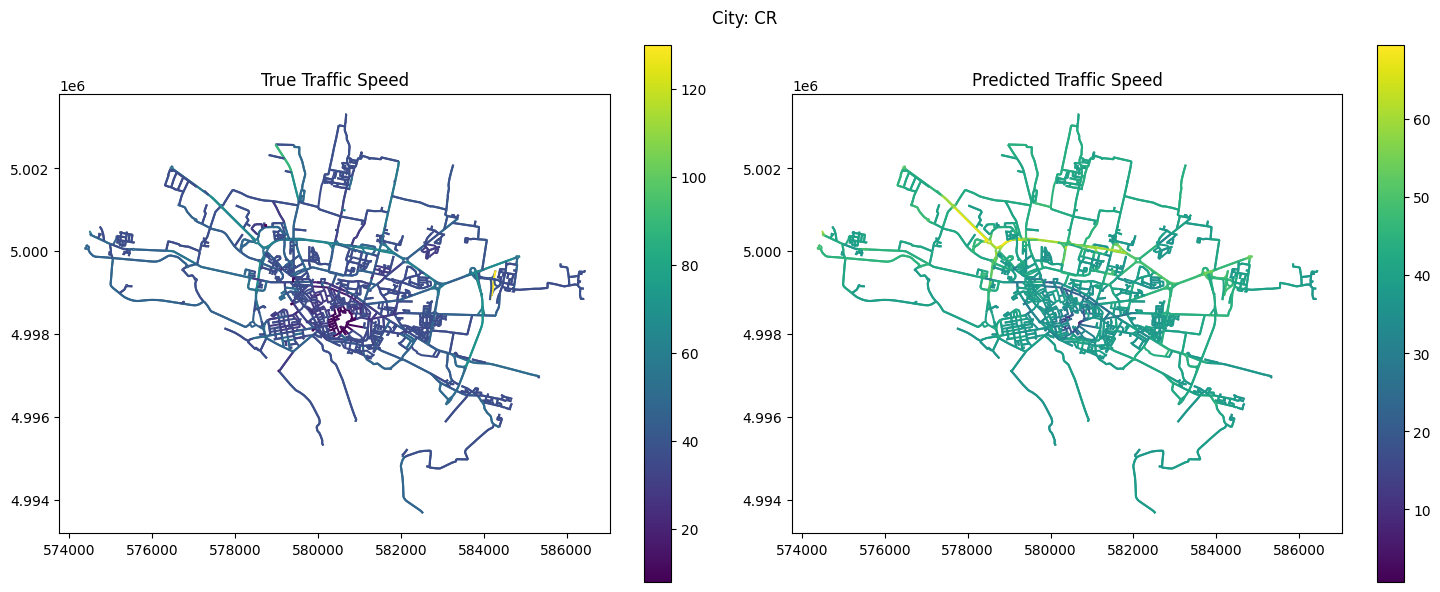

In [116]:
plot_predictions('CR', model, processed_data, edges)

In [117]:
#evaluate on VR and FE
vr_data = vr_data.to(device)
vr_test_loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {vr_test_loss:.4f}")
fe_data = fe_data.to(device)
fe_test_loss = test(model, fe_data, fe_data.test_mask)
print(f"Test Loss for FE: {fe_test_loss:.4f}")

Test Loss for VR: 75.7536
Test Loss for FE: 65.8630


Honestly I don't see any clear advantage of this model over the first one.

## Second model is like GPS:
It combines Performer and GNN at each layer.
Just like GPS I give the GNN the positional encoding.

In [118]:
class HybridModelv2(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_layers: int = 3,
        dropout: float = 0.4,
        combine_method: str = 'sum',  # 'sum', 'concat'
    ):
        super().__init__()
        
        # Input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        # GPS layers
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # Transformer component
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                
                # GAT component
                'gat': GATConv(hidden_channels, hidden_channels // heads, 
                               heads=heads, concat=True, dropout=dropout),
                
                # Combination method
                'combine': self._make_combiner(combine_method, hidden_channels),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.layers.append(layer)
        
        # Output layer for edge prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def _make_combiner(self, method, hidden_channels):
        if method == 'sum':
            return nn.Identity()
        elif method == 'concat':
            return nn.Sequential(
                nn.Linear(hidden_channels * 2, hidden_channels),
                nn.ReLU()
            )
        
    
    def forward(self, x, pe, edge_index, batch=None):
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Process through GPS layers
        for layer in self.layers:
            # Pre-normalization
            x_norm = layer['norm'](x)
            
            # Transformer component
            x_trans = x_norm.unsqueeze(0)
            x_trans = layer['attention'](x_trans).squeeze(0)
            
            # GAT component
            x_gat = layer['gat'](x_norm, edge_index)
            
            # Combine the outputs with residual connection
            if isinstance(layer['combine'], nn.Identity):  # Sum
                x_combined = x_trans + x_gat + x  # Residual
            elif isinstance(layer['combine'], nn.Sequential):  # Concat
                x_combined = layer['combine'](torch.cat([x_trans, x_gat], dim=1)) + x
            
            # Feed-forward network with residual
            x = x_combined + layer['ffn'](x_combined)
        
        # Edge prediction
        src, dst = edge_index
        edge_features = torch.cat([x[src], x[dst]], dim=1)
        edge_pred = self.output_layer(edge_features)
        
        return edge_pred
    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.layers:
            layer['attention'].redraw_projection_matrix()

In [119]:
device = 'cpu' #GAT do not support mps yet
model = HybridModelv2(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)

HybridModelv2(
  (node_emb): Linear(in_features=6, out_features=48, bias=True)
  (pe_lin): Linear(in_features=20, out_features=16, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): ModuleList(
    (0-1): 2 x ModuleDict(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): PerformerAttention(heads=4, head_channels=16 kernel=ReLU())
      (gat): GATConv(64, 16, heads=4)
      (combine): Identity()
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): Dropout(p=0.4, inplace=False)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
    )
  )
  (output_layer): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [120]:
# Train and evaluate the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=60)
redraw_freq = 30
def train(model, data):
    model.train()
    optimizer.zero_grad()
    if epoch % redraw_freq == 0:
        model.redraw_projection_matrix()
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    loss = criterion(predictions[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()
def test(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask]
        pred = pred.squeeze(-1)
        true = data.y[mask]
        loss = criterion(pred, true)
        return loss.item()

In [121]:
# Train loop
EPOCHS = 1000
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # Reset epoch losses
    epoch_train_loss = 0
    epoch_val_loss = 0
    num_batches = 0
    
    # Process all batches in an epoch
    for batch in loader:
        batch = batch.to(device)
        train_loss = train(model, batch)
        val_loss = test(model, batch, batch.val_mask)
        
        # Accumulate batch losses
        epoch_train_loss += train_loss
        epoch_val_loss += val_loss
        num_batches += 1
    
    # Calculate average losses for the epoch
    epoch_train_loss /= num_batches
    epoch_val_loss /= num_batches
    
    # Record epoch losses
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    # Scheduler step with average validation loss
    scheduler.step(epoch_val_loss)
    
    # Early stopping based on epoch validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_gpslike_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

Epoch 10: Train Loss: 130.1462, Val Loss: 73.9341
Epoch 20: Train Loss: 112.2202, Val Loss: 64.7234
Epoch 30: Train Loss: 104.4831, Val Loss: 63.1558
Epoch 40: Train Loss: 101.3297, Val Loss: 60.9422
Epoch 50: Train Loss: 98.0476, Val Loss: 60.4338
Epoch 60: Train Loss: 96.7037, Val Loss: 61.1482
Epoch 70: Train Loss: 95.7368, Val Loss: 62.1551
Epoch 80: Train Loss: 93.7266, Val Loss: 61.1871
Epoch 90: Train Loss: 95.9677, Val Loss: 63.9739
Epoch 100: Train Loss: 90.0265, Val Loss: 59.0518
Epoch 110: Train Loss: 88.7118, Val Loss: 58.8361
Epoch 120: Train Loss: 94.0308, Val Loss: 65.3179
Epoch 130: Train Loss: 85.8304, Val Loss: 57.6662
Epoch 140: Train Loss: 86.0110, Val Loss: 58.4835
Epoch 150: Train Loss: 93.7756, Val Loss: 67.2039
Epoch 160: Train Loss: 82.8731, Val Loss: 59.5052
Epoch 170: Train Loss: 82.0585, Val Loss: 58.6283
Epoch 180: Train Loss: 91.0533, Val Loss: 62.8246
Epoch 190: Train Loss: 81.9678, Val Loss: 58.1270
Epoch 200: Train Loss: 80.3595, Val Loss: 60.2454
Epoch

In [122]:
# load the model
model = HybridModelv2(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=2,
    dropout=0.4,
    combine_method='sum'
)
# Load the best model
model.load_state_dict(torch.load('best_gpslike_model.pth'))
model.to(device)

# Evaluate the model on the test set per city
test_losses = {}
for city, data in processed_data.items():
    data = data.to(device)
    test_loss = test(model, data, data.test_mask)
    test_losses[city] = test_loss
    print(f"Test Loss for {city}: {test_loss:.4f}")

Test Loss for PC: 54.1480
Test Loss for CR: 54.5053
Test Loss for PU: 63.7119
Test Loss for TR: 67.6242
Test Loss for RI: 51.2436


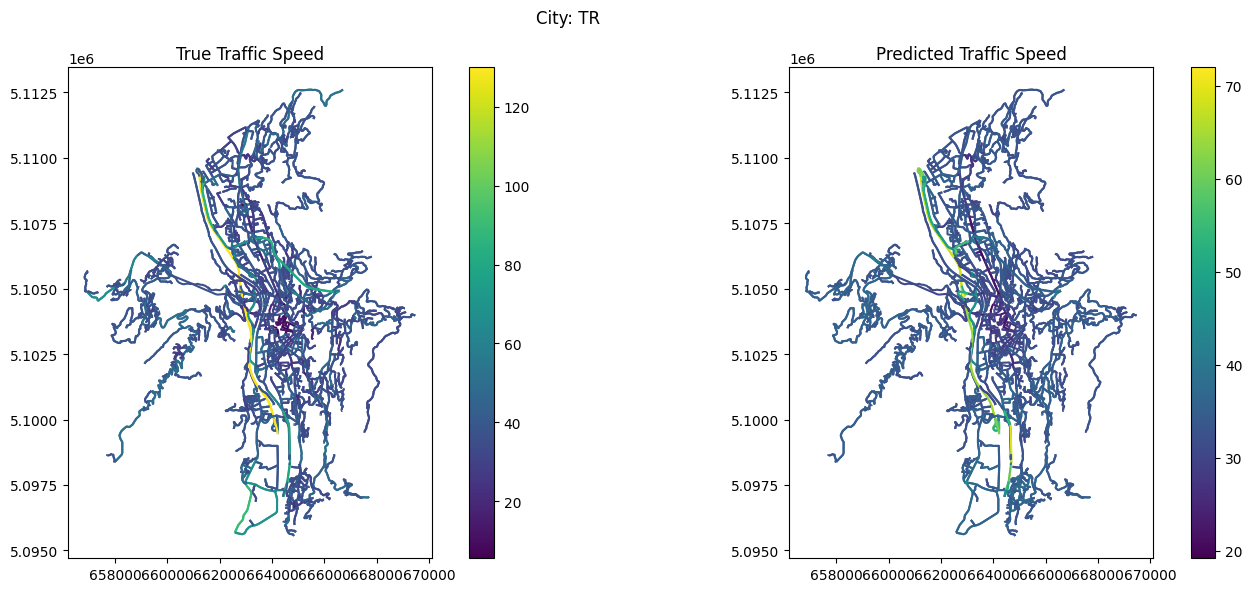

In [127]:
plot_predictions('TR', model, processed_data, edges)

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


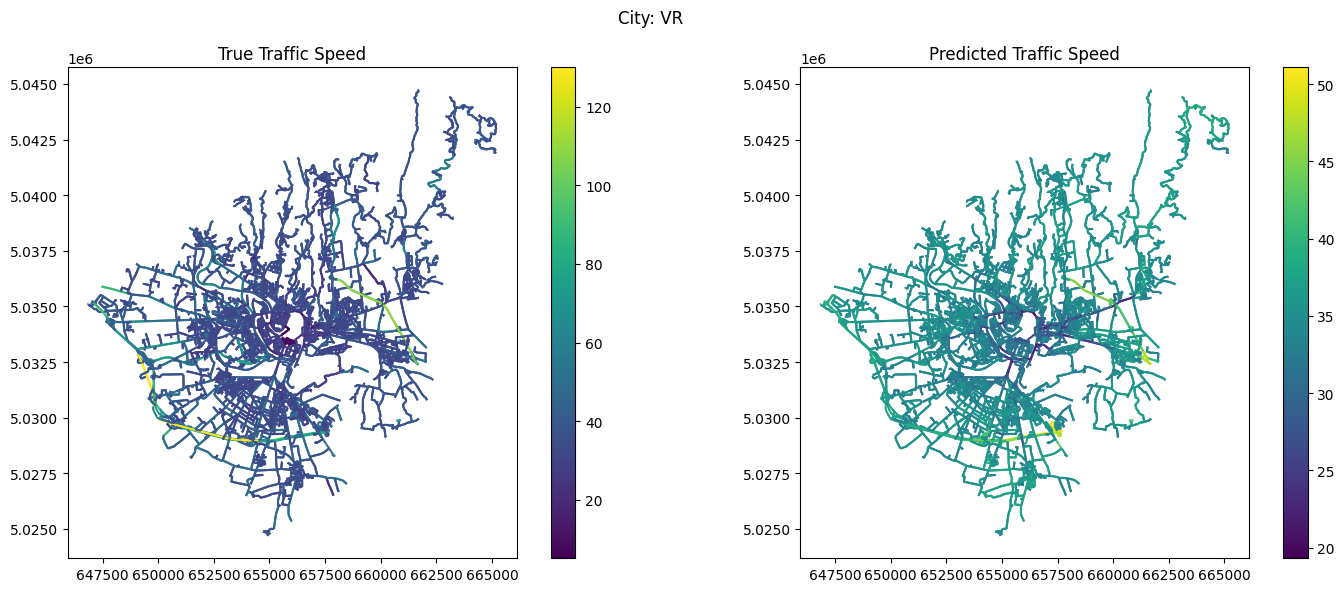

Test Loss for VR: 64.5130


In [128]:
#import a new city to test
nodes_vr = gpd.read_file(f'nodes_VR.geojson')
edges_vr = gpd.read_file(f'edges_VR.geojson')

nodes_vr = nodes_vr[[col for col in nodes_vr.columns if col in node_columns]]

vr_data = preprocess_data(nodes_vr, edges_vr)
plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})

#compute loss
vr_data = vr_data.to(device)
vr_test_loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {vr_test_loss:.4f}")

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5


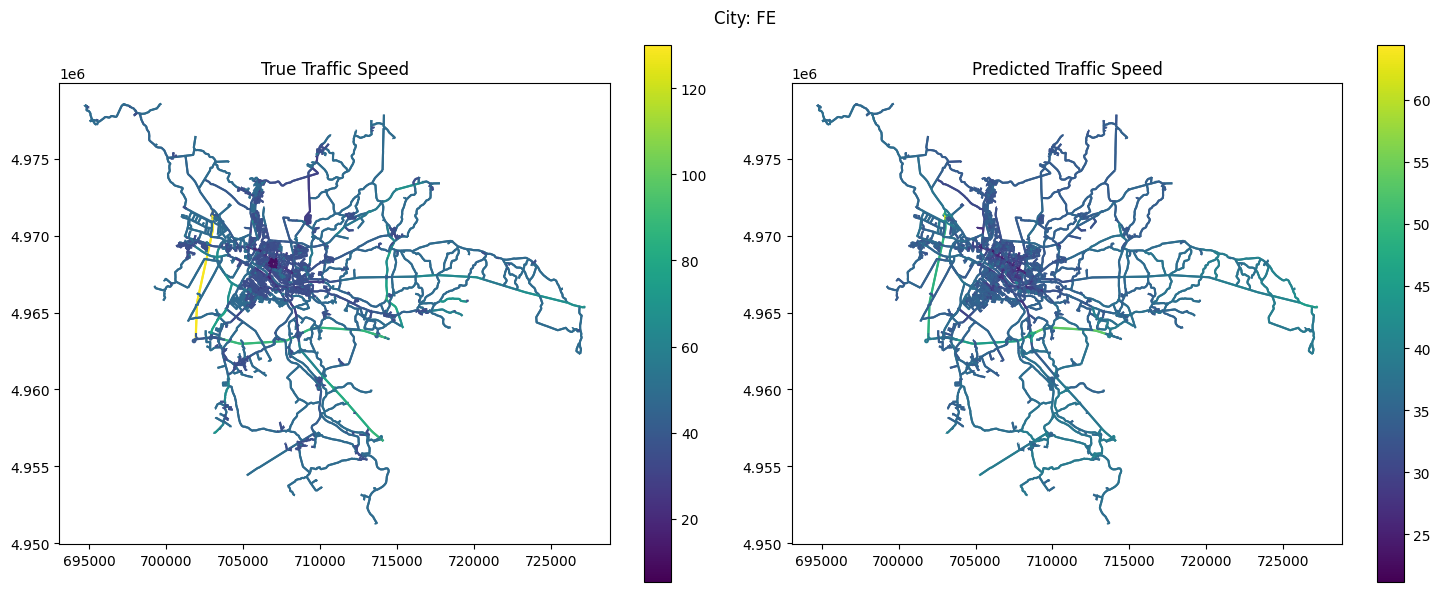

Test Loss for FE: 106.2438


In [129]:
#import a new city to test
nodes_fe = gpd.read_file(f'nodes_FE.geojson')
edges_fe = gpd.read_file(f'edges_FE.geojson')

nodes_fe = nodes_fe[[col for col in nodes_fe.columns if col in node_columns]]

fe_data = preprocess_data(nodes_fe, edges_fe)
plot_predictions('FE', model, {'FE': fe_data}, {'FE': edges_fe})

#compute loss
fe_data = fe_data.to(device)
fe_test_loss = test(model, fe_data, fe_data.test_mask)
print(f"Test Loss for FE: {fe_test_loss:.4f}")

Until now the three models do not have any clear advantage over the other.

## Third model is GPS:
It combines Performer and GNN at each layer.

In [38]:
from typing import Optional
from torch.nn import Linear, Sequential, ReLU, ModuleList, BatchNorm1d
from torch_geometric.nn import GINConv, GPSConv

class RedrawProjection:
    def __init__(self, model: torch.nn.Module,
                redraw_interval: Optional[int] = None):
        self.model = model
        self.redraw_interval = redraw_interval
        self.num_last_redraw = 0

    def redraw_projections(self):
        if not self.model.training or self.redraw_interval is None:
            return
        if self.num_last_redraw >= self.redraw_interval:
            fast_attentions = [
                module for module in self.model.modules()
                if isinstance(module, PerformerAttention)
            ]
            for fast_attention in fast_attentions:
                fast_attention.redraw_projection_matrix()
            self.num_last_redraw = 0
            return
        self.num_last_redraw += 1

class GPS(torch.nn.Module):
    def __init__(self, channels: int, pe_dim: int, num_layers: int,
                 attn_type: str = 'performer', dropout: float = 0.0):
        super().__init__()

        self.node_emb = Linear(data.x.shape[1], channels - pe_dim)
        self.pe_lin = Linear(20, pe_dim)
        self.pe_norm = BatchNorm1d(20)

        self.convs = ModuleList()
        for _ in range(num_layers):
            nn = Sequential(
                Linear(channels, channels),
                ReLU(),
                Linear(channels, channels),
            )
            conv = GPSConv(channels, GINConv(nn), heads=4,
                           attn_type=attn_type, dropout=dropout)
            self.convs.append(conv)

        self.mlp = Sequential(
            Linear(2* channels, channels),
            ReLU(),
            Linear(channels, 1)
            
        )
        self.redraw_projection = RedrawProjection(
            self.convs,
            redraw_interval=30 if attn_type == 'performer' else None)

    def forward(self, x, pe, edge_index):
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        

        for conv in self.convs:
            x = conv(x, edge_index)
        
        # Edge-level prediction
        src, dst = edge_index
        x = torch.cat((x[src], x[dst]), dim=1)
        
        x = self.mlp(x)
        return x
    
device = 'cpu'

model = GPS(channels= 64, pe_dim=8, num_layers=2, attn_type= 'performer',
            dropout= 0.5).to(device)

In [39]:
# Train and evaluate the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=60)
redraw_freq = 30
def train(model, data):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    loss = criterion(predictions[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()
def test(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask]
        pred = pred.squeeze(-1)
        true = data.y[mask]
        loss = criterion(pred, true)
        return loss.item()

In [40]:
# Train loop
EPOCHS = 1000
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # Reset epoch losses
    epoch_train_loss = 0
    epoch_val_loss = 0
    num_batches = 0
    
    # Process all batches in an epoch
    for batch in loader:
        batch = batch.to(device)
        train_loss = train(model, batch)
        val_loss = test(model, batch, batch.val_mask)
        
        # Accumulate batch losses
        epoch_train_loss += train_loss
        epoch_val_loss += val_loss
        num_batches += 1
    
    # Calculate average losses for the epoch
    epoch_train_loss /= num_batches
    epoch_val_loss /= num_batches
    
    # Record epoch losses
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    # Scheduler step with average validation loss
    scheduler.step(epoch_val_loss)
    
    # Early stopping based on epoch validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_gps.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

Epoch 10: Train Loss: 974.8850, Val Loss: 818.8777
Epoch 20: Train Loss: 107.6532, Val Loss: 149.3428
Epoch 30: Train Loss: 87.5175, Val Loss: 94.5890
Epoch 40: Train Loss: 78.3501, Val Loss: 70.6512
Epoch 50: Train Loss: 70.1261, Val Loss: 65.9834
Epoch 60: Train Loss: 65.4163, Val Loss: 63.0471
Epoch 70: Train Loss: 63.2520, Val Loss: 61.1190
Epoch 80: Train Loss: 60.1205, Val Loss: 60.3661
Epoch 90: Train Loss: 59.4747, Val Loss: 61.8312
Epoch 100: Train Loss: 55.6537, Val Loss: 60.9611
Epoch 110: Train Loss: 53.2822, Val Loss: 61.5064
Epoch 120: Train Loss: 53.2616, Val Loss: 58.3601
Epoch 130: Train Loss: 51.5399, Val Loss: 62.3820
Epoch 140: Train Loss: 50.8976, Val Loss: 67.1588
Epoch 150: Train Loss: 47.8936, Val Loss: 56.6375
Epoch 160: Train Loss: 49.0644, Val Loss: 60.8008
Epoch 170: Train Loss: 47.5773, Val Loss: 56.3614
Epoch 180: Train Loss: 46.4631, Val Loss: 52.8704
Epoch 190: Train Loss: 48.5340, Val Loss: 52.3211
Epoch 200: Train Loss: 44.2698, Val Loss: 52.3596
Epoch

In [41]:
# load the model
model = GPS(channels= 64, pe_dim=8, num_layers=2, attn_type= 'performer',
            dropout= 0.5).to(device)
# Load the best model
model.load_state_dict(torch.load('best_gps.pth'))
model.to(device)


# Evaluate the model on the test set per city
test_losses = {}
for city, data in processed_data.items():
    data = data.to(device)
    test_loss = test(model, data, data.test_mask)
    test_losses[city] = test_loss
    print(f"Test Loss for {city}: {test_loss:.4f}")

Test Loss for PC: 67.2126
Test Loss for CR: 43.1143
Test Loss for PU: 45.7965
Test Loss for TR: 51.4297
Test Loss for RI: 35.5160


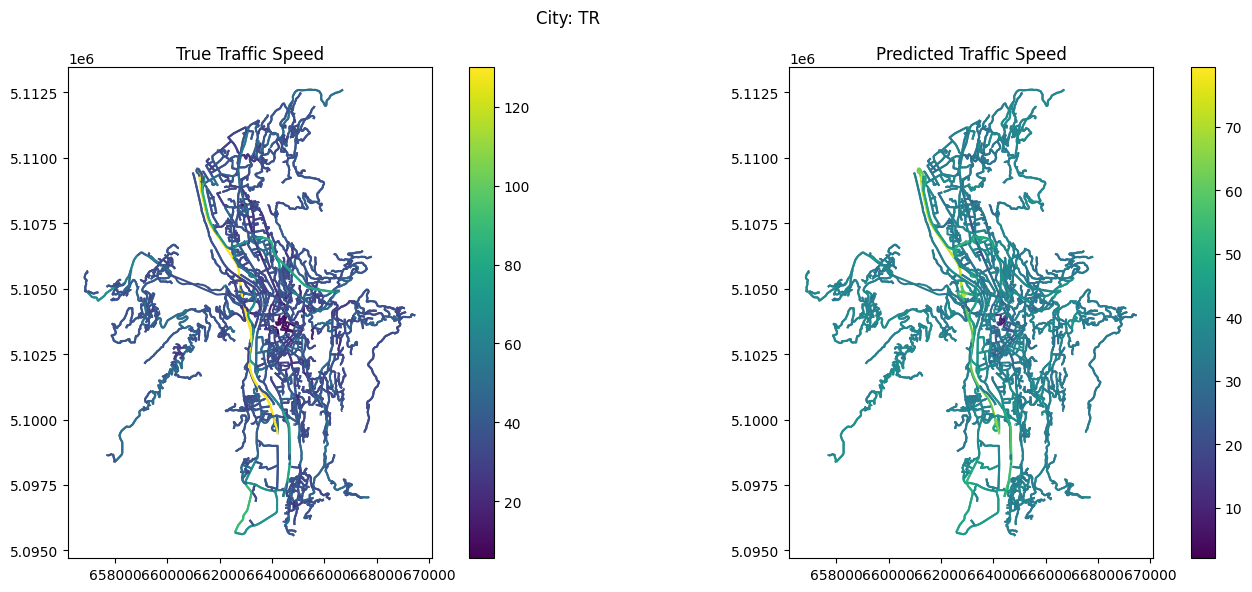

In [45]:
plot_predictions('TR', model, processed_data, edges)

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


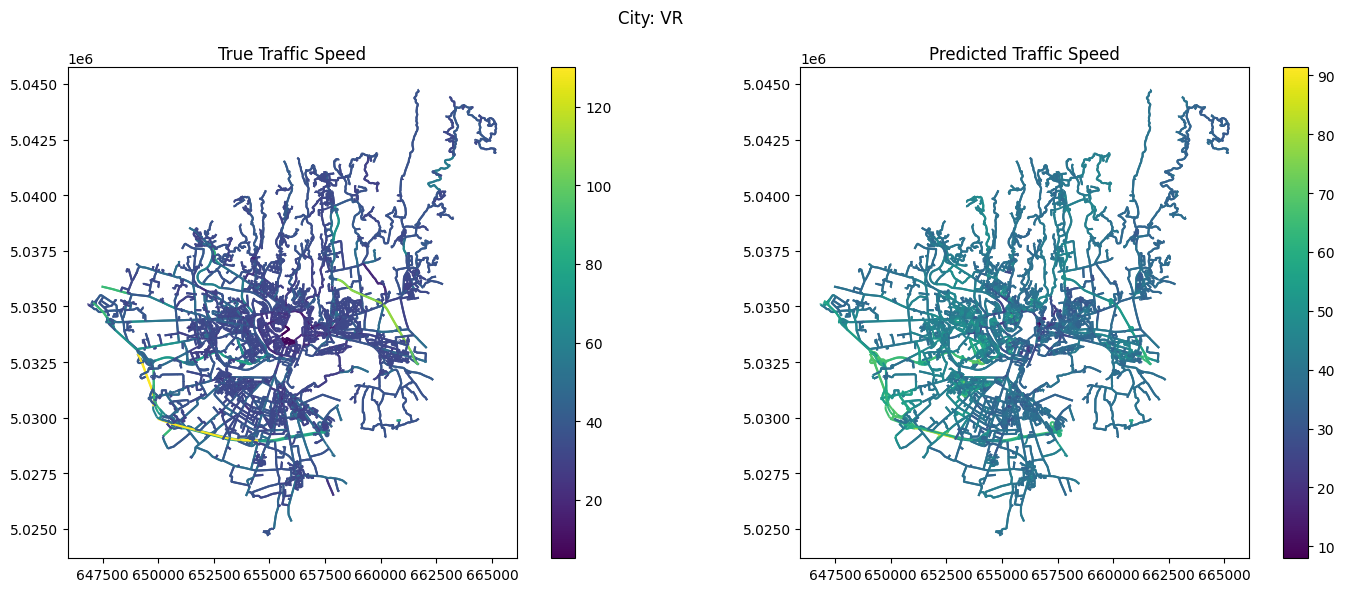

Test Loss for VR: 100.7034


In [46]:
#import a new city to test
nodes_vr = gpd.read_file(f'nodes_VR.geojson')
edges_vr = gpd.read_file(f'edges_VR.geojson')

nodes_vr = nodes_vr[[col for col in nodes_vr.columns if col in node_columns]]

vr_data = preprocess_data(nodes_vr, edges_vr)
plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})

#compute loss
vr_data = vr_data.to(device)
vr_test_loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {vr_test_loss:.4f}")

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5


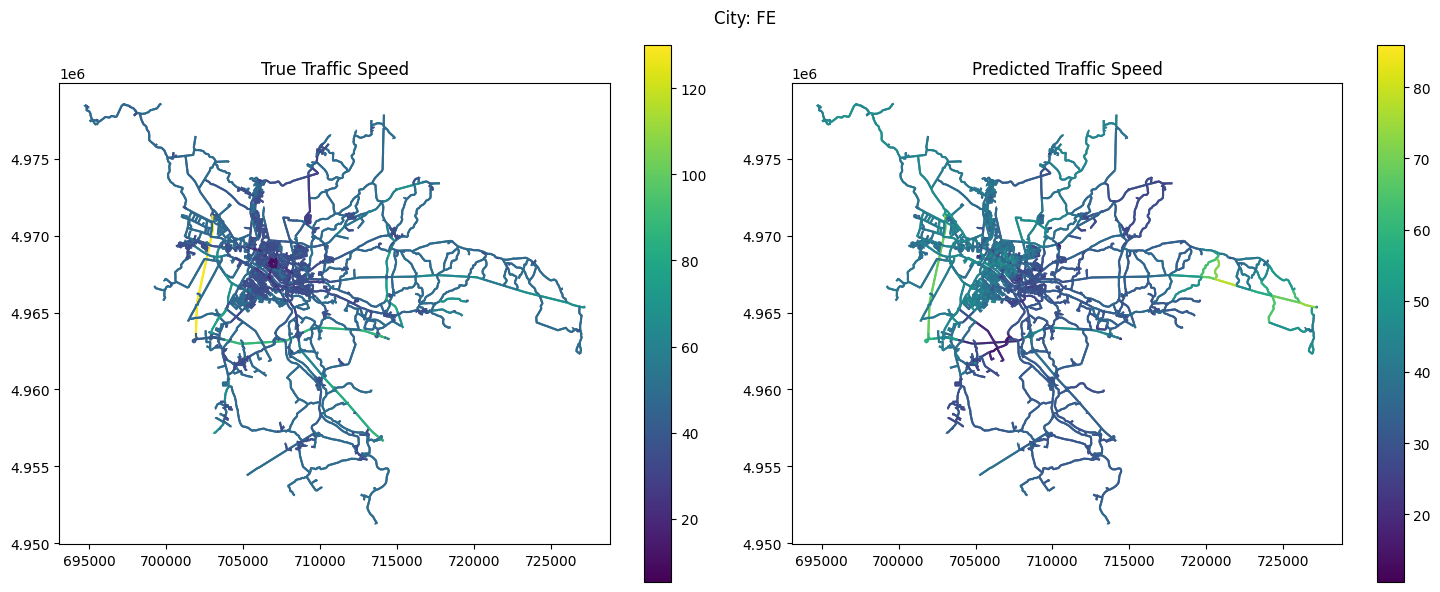

Test Loss for FE: 120.7501


In [47]:
#import a new city to test
nodes_fe = gpd.read_file(f'nodes_FE.geojson')
edges_fe = gpd.read_file(f'edges_FE.geojson')

nodes_fe = nodes_fe[[col for col in nodes_fe.columns if col in node_columns]]

fe_data = preprocess_data(nodes_fe, edges_fe)
plot_predictions('FE', model, {'FE': fe_data}, {'FE': edges_fe})

#compute loss
fe_data = fe_data.to(device)
fe_test_loss = test(model, fe_data, fe_data.test_mask)
print(f"Test Loss for FE: {fe_test_loss:.4f}")

# Fine-tuning part
We have multiple models saved, so no need to train them again.
We can try various types of fine-tuning.
## Fine-tuning with various percentage of nodes, uniformely distributed in space

In [155]:
from sklearn.neighbors import NearestNeighbors

def create_spatial_finetune_mask(node_data, edge_index, percentage=0.05, seed=0):
    """
    Create a fine-tuning mask using nearest neighbors to sample nodes uniformly in space.
    
    Args:
        node_data: DataFrame with node data containing 'x' and 'y' coordinates
        edge_index: PyTorch tensor with edge indices
        percentage: Percentage of nodes to sample for fine-tuning
        seed: Random seed for reproducibility
        
    Returns:
        edge_mask: Boolean mask for edges connected to sampled nodes
    """
    np.random.seed(seed)
    
    # Extract spatial coordinates
    x_coords = node_data['x'].values
    y_coords = node_data['y'].values
    coordinates = np.column_stack([x_coords, y_coords])
    
    # Determine spatial bounds
    x_min, x_max = np.min(x_coords), np.max(x_coords)
    y_min, y_max = np.min(y_coords), np.max(y_coords)
    
    # Calculate number of points to sample
    num_nodes = len(node_data)
    num_points_to_sample = int(percentage * num_nodes)
    
    # Generate random points uniformly across the space
    random_points = np.column_stack([
        np.random.uniform(x_min, x_max, num_points_to_sample),
        np.random.uniform(y_min, y_max, num_points_to_sample)
    ])
    
    # Find nearest nodes to each random point
    nn = NearestNeighbors(n_neighbors=1).fit(coordinates)
    distances, indices = nn.kneighbors(random_points)
    
    # Get unique nearest nodes (may be fewer than random points if multiple points map to same node)
    selected_node_indices = np.unique(indices.flatten())
    
    # Create node mask
    node_mask = torch.zeros(num_nodes, dtype=torch.bool)
    node_mask[selected_node_indices] = True
    
    # Create edge mask - include edges that connect to selected nodes
    sources, targets = edge_index
    edge_mask = torch.zeros(edge_index.shape[1], dtype=torch.bool)
    
    for i, (src, dst) in enumerate(zip(sources, targets)):
        if node_mask[src] or node_mask[dst]:
            edge_mask[i] = True
            
    return edge_mask

<Axes: >

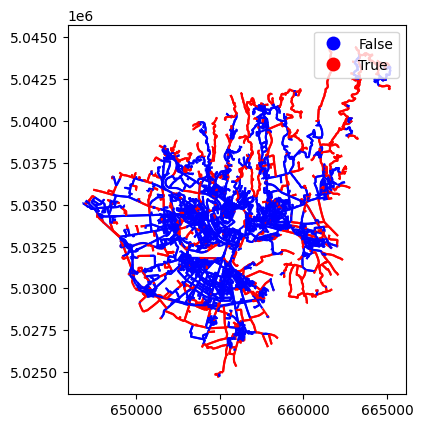

In [203]:
# VR finetune mask

vr_finetune_mask = create_spatial_finetune_mask(nodes_vr, vr_data.edge_index, percentage=0.15, seed=1)
#plot the mask
edges_vr['finetune_mask'] = vr_finetune_mask.cpu().numpy()
edges_vr.plot(column='finetune_mask', cmap='bwr', legend=True)

In [204]:
out = model(vr_data.x, vr_data.pe, vr_data.edge_index)
predictions = out.squeeze(-1)
print(predictions.shape)
print(predictions[vr_finetune_mask].shape)
print(vr_data.y[vr_finetune_mask].shape)

torch.Size([13798])
torch.Size([1563])
torch.Size([1563])


In [214]:
# load model for finetuning
model = HybridModelv2(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)
# Load the best model
model.load_state_dict(torch.load('best_gpslike_model.pth'))
model.to(device)

loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {loss:.4f}")

Test Loss for VR: 64.5130


In [215]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def finetune(model, data, ft_mask):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass on full graph
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    
    # Loss only on masked edges
    loss = criterion(predictions[ft_mask], data.y[ft_mask])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [216]:
# Fine-tuning loop
FINETUNE_EPOCHS = 50  # Reduced from 1000 in original training
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30  # Reduced from 100
ft_train_losses, ft_val_losses = [], []


for epoch in range(1, FINETUNE_EPOCHS + 1):
    # Training on fine-tuning mask
    ft_loss = finetune(model, vr_data, vr_finetune_mask)
    # Validation on original validation set
    val_loss = test(model, vr_data, vr_data.val_mask)
    
    # Scheduler and early stopping logic
    #scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_finetuned_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 5 == 0:  # Report more frequently
        print(f"FT Epoch {epoch}: Train Loss: {ft_loss:.4f}, Val Loss: {val_loss:.4f}")

FT Epoch 5: Train Loss: 137.0996, Val Loss: 79.0488
FT Epoch 10: Train Loss: 122.3419, Val Loss: 66.5251
FT Epoch 15: Train Loss: 117.3867, Val Loss: 63.8834
FT Epoch 20: Train Loss: 126.5703, Val Loss: 69.3827
FT Epoch 25: Train Loss: 116.4429, Val Loss: 65.2668
FT Epoch 30: Train Loss: 116.4346, Val Loss: 64.0782
FT Epoch 35: Train Loss: 115.1082, Val Loss: 64.3169
FT Epoch 40: Train Loss: 103.7908, Val Loss: 63.7564
FT Epoch 45: Train Loss: 111.8697, Val Loss: 64.9078
FT Epoch 50: Train Loss: 107.4810, Val Loss: 61.6846


Test Loss for VR after fine-tuning: 53.3814


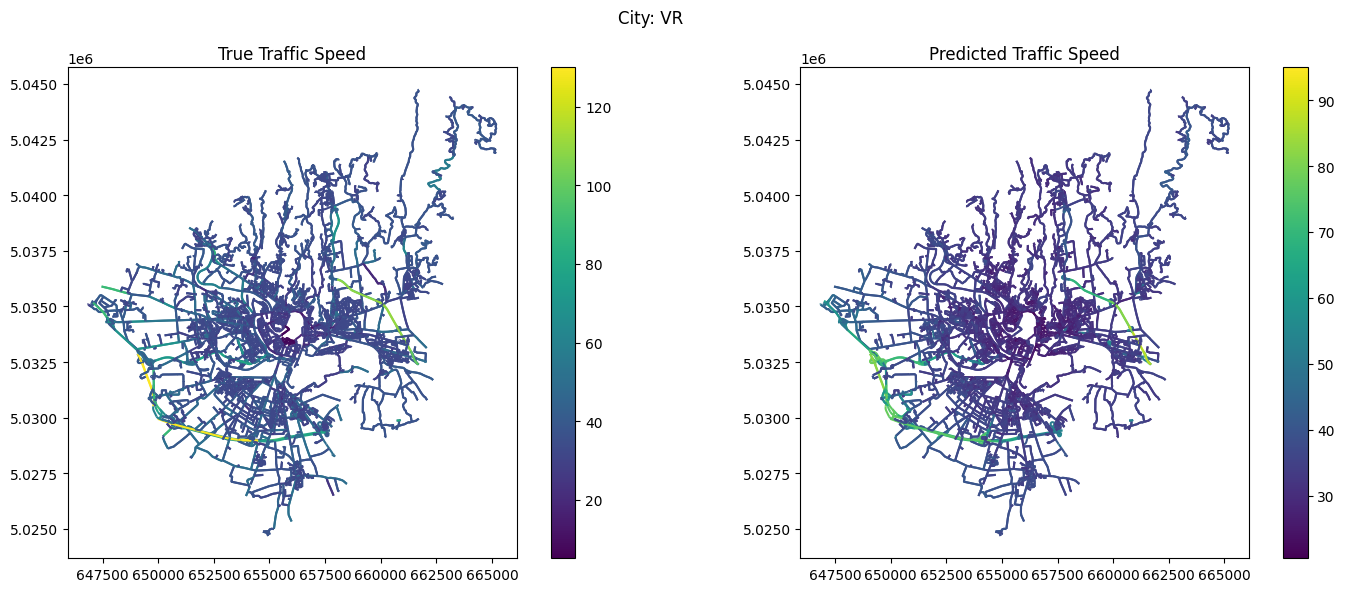

In [218]:
# Load the best fine-tuned model
model = HybridModelv2(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.load_state_dict(torch.load('best_finetuned_model.pth'))
model.to(device)

loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR after fine-tuning: {loss:.4f}")

plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})

From my very small sample of tests, it seems that the gps like model is the one that learns the best.

## Fine-tuning with a spatial mask that shows only a portion of the city
I would expect this way of fine-tuning to be way worse since the model will not even see a single node of other regions.

In [246]:
def create_region_finetune_mask(node_data, edge_index, region_params=None):
    """
    Create a fine-tuning mask for nodes in a specific region of the city.
    
    Args:
        node_data: DataFrame with node data containing 'x' and 'y' coordinates
        edge_index: PyTorch tensor with edge indices
        region_params: Parameters for the region (quadrant): 'NE', 'NW', 'SE', 'SW'
        seed: Random seed for reproducibility
        
    Returns:
        edge_mask: Boolean mask for edges connected to nodes in the region
    """
    
    # Extract spatial coordinates
    x_coords = node_data['x'].values
    y_coords = node_data['y'].values
    
    # Determine spatial bounds of the entire city
    x_min, x_max = np.min(x_coords), np.max(x_coords)
    y_min, y_max = np.min(y_coords), np.max(y_coords)
    
    if region_params is None:
        region_params = 'SW'  # Default to southwest quadrant
    
    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    
    if region_params == 'NE':
        node_mask = (x_coords >= x_center) & (y_coords >= y_center)
    elif region_params == 'NW':
        node_mask = (x_coords <= x_center) & (y_coords >= y_center)
    elif region_params == 'SE':
        node_mask = (x_coords >= x_center) & (y_coords <= y_center)
    elif region_params == 'SW':
        node_mask = (x_coords <= x_center) & (y_coords <= y_center)
    elif region_params == 'N':
        node_mask = (y_coords >= y_center)
    elif region_params == 'S':
        node_mask = (y_coords <= y_center)
    elif region_params == 'E':
        node_mask = (x_coords >= x_center)
    elif region_params == 'W':
        node_mask = (x_coords <= x_center)
    elif region_params == 'C':
        radius = min(x_max - x_min, y_max - y_min) / 6
        node_mask = ((x_coords - x_center) ** 2 + (y_coords - y_center) ** 2) <= radius ** 2
    else:
        raise ValueError(f"Invalid quadrant: {region_params}")
    
    # Convert NumPy boolean array to PyTorch tensor
    node_mask = torch.tensor(node_mask, dtype=torch.bool)
    
    # Create edge mask - include edges that connect to selected nodes
    sources, targets = edge_index
    edge_mask = torch.zeros(edge_index.shape[1], dtype=torch.bool)
    
    for i, (src, dst) in enumerate(zip(sources, targets)):
        if node_mask[src] or node_mask[dst]:
            edge_mask[i] = True
            
    return edge_mask

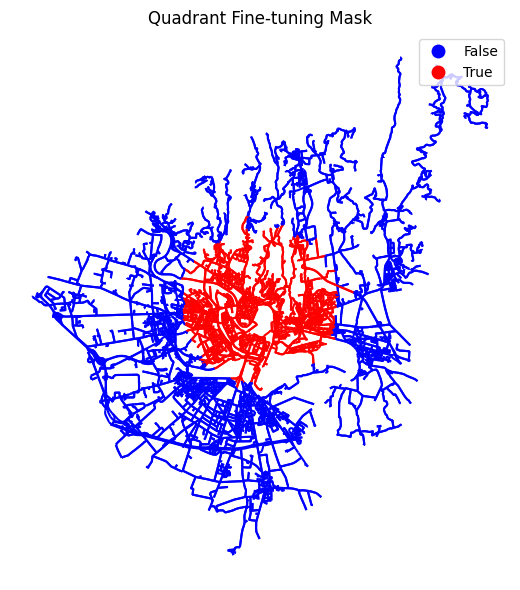

In [ ]:
#check how the mask looks like
quadrant_mask = create_region_finetune_mask(nodes_vr, vr_data.edge_index, region_params='C')
# Visualize the masks
edges_vr['quadrant_mask'] = quadrant_mask.cpu().numpy()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
edges_vr.plot(column='quadrant_mask', cmap='bwr', legend=True, ax=ax)
plt.title('Quadrant Fine-tuning Mask')
plt.axis('off')
plt.tight_layout()
plt.show()


Test Loss for VR: 75.7536


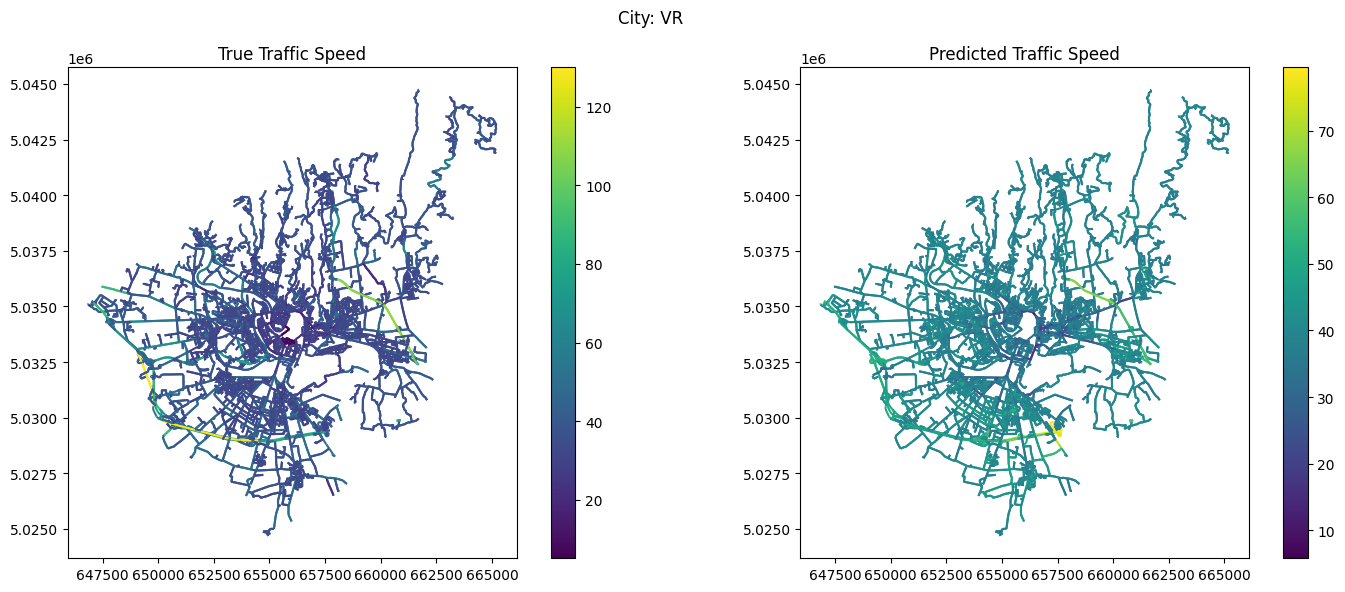

In [272]:
# Load the model for fine-tuning
model = HybridModel_variant(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)
# Load the best model
model.load_state_dict(torch.load('best_model_var.pth'))
model.to(device)

loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR: {loss:.4f}")
plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})

In [273]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def finetune(model, data, ft_mask):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass on full graph
    out = model(data.x, data.pe, data.edge_index)
    predictions = out.squeeze(-1)
    
    # Loss only on masked edges
    loss = criterion(predictions[ft_mask], data.y[ft_mask])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [274]:
vr_finetune_mask = create_region_finetune_mask(nodes_vr, vr_data.edge_index, region_params='C')
# Fine-tuning loop
FINETUNE_EPOCHS = 50  # Reduced from 1000 in original training
best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30  # Reduced from 100
ft_train_losses, ft_val_losses = [], []


for epoch in range(1, FINETUNE_EPOCHS + 1):
    # Training on fine-tuning mask
    ft_loss = finetune(model, vr_data, vr_finetune_mask)
    # Validation on original validation set
    val_loss = test(model, vr_data, vr_data.val_mask)
    
    # Scheduler and early stopping logic
    #scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_region_finetuned_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 5 == 0:  # Report more frequently
        print(f"FT Epoch {epoch}: Train Loss: {ft_loss:.4f}, Val Loss: {val_loss:.4f}")

FT Epoch 5: Train Loss: 67.6281, Val Loss: 73.4641
FT Epoch 10: Train Loss: 64.6198, Val Loss: 70.3796
FT Epoch 15: Train Loss: 60.9694, Val Loss: 70.1852
FT Epoch 20: Train Loss: 60.6888, Val Loss: 68.1399
FT Epoch 25: Train Loss: 58.3750, Val Loss: 69.8845
FT Epoch 30: Train Loss: 59.1177, Val Loss: 74.6075
FT Epoch 35: Train Loss: 56.0462, Val Loss: 74.5797
FT Epoch 40: Train Loss: 56.7794, Val Loss: 77.5479
FT Epoch 45: Train Loss: 54.7593, Val Loss: 77.3165
Early stopping at epoch 48


Test Loss for VR after fine-tuning: 52.6470


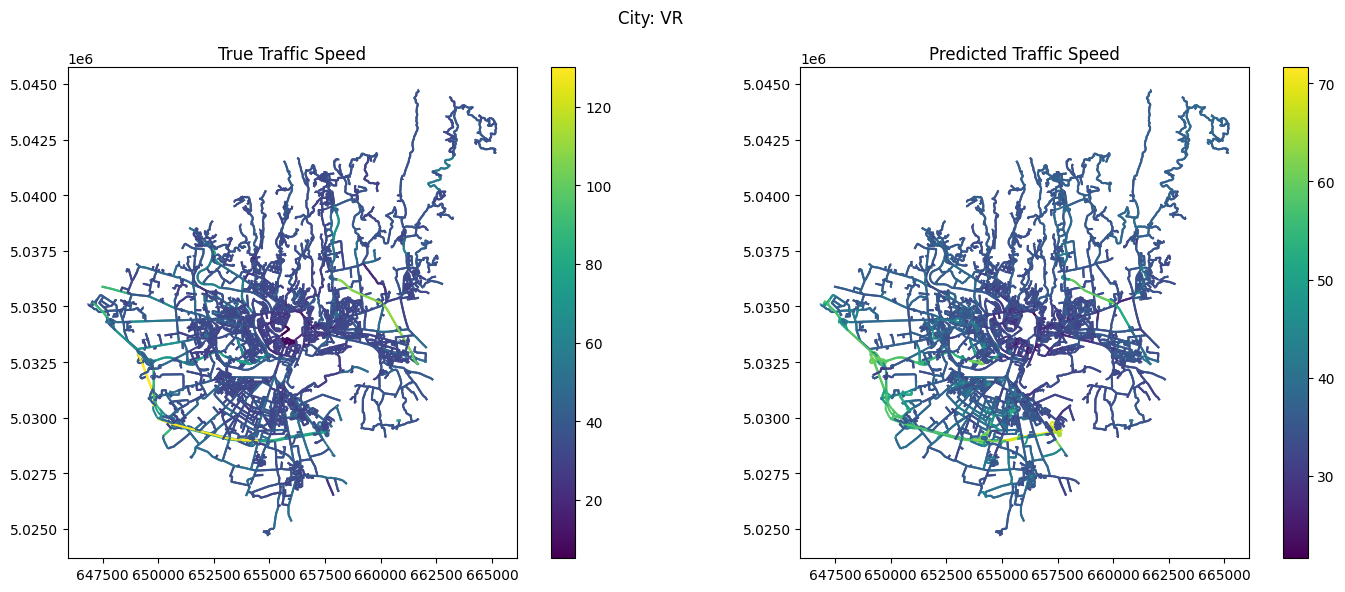

In [275]:
# Load the best fine-tuned model
model = HybridModel_variant(
    in_channels=processed_data['TR'].num_features,
    pe_input_dim=processed_data['TR'].pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_transformer_layers=2,
    num_gat_layers=2,
    dropout=0.4,
    combine_method='sum'
)
model.load_state_dict(torch.load('best_region_finetuned_model.pth'))
model.to(device)

loss = test(model, vr_data, vr_data.test_mask)
print(f"Test Loss for VR after fine-tuning: {loss:.4f}")

plot_predictions('VR', model, {'VR': vr_data}, {'VR': edges_vr})